# Time Series Analysis of Bitcoin Transaction Volume (2009–2026)

**Course:** TSAC 2025/2026

**Due Date:** March 29th, 2026

---

## Abstract

This project analyzes Bitcoin transaction volume recorded every 4 days from January 2009 to March 2026, yielding 1,568 observations. The series exhibited strong non-stationarity, which was addressed through log transformation and first differencing. An ARIMA(2,1,3) model with drift was selected based on the Akaike Information Criterion. When applied to a holdout set of 10 observations, the model achieved a Mean Absolute Percentage Error of 0.92% and a MASE of 0.68, outperforming a naïve benchmark. The main limitation identified is the structural difference between Bitcoin's early era (2009–2012) and its modern behavior.

---

## 1. Introduction

Bitcoin is a decentralized digital currency introduced in January 2009. Unlike traditional financial assets, it operates without a central bank or single administrator. One of its most fundamental measurable quantities is transaction volume - the number of confirmed transactions processed on the blockchain per unit time. Understanding and forecasting this volume is relevant for several reasons: it reflects network adoption and usage, it correlates with market activity, and it serves as a proxy for the overall health of the Bitcoin ecosystem.

This project applies classical time series methodology to model and forecast Bitcoin transaction volume. The data was obtained from Blockchain.com and spans from January 2009 to March 2026, sampled every 4 days. With over 1,500 observations covering Bitcoin's entire history - from its first transaction to its current status as a globally traded asset - this dataset offers a rare opportunity to study the long-run dynamics of a revolutionary financial technology.

# Phase 1: Data Preparation

In this phase, we begin by installing the required packages to work with the data:
- `jsonlite` for reading JSON files
- `dplyr` for data manipulation
- `ggplot2` for visualization

We then load and extract the relevant data, carefully examining its structure to understand the variables and their formats.

Next, we convert the timestamp column to a proper Date format, followed by cleaning and formatting the dataframe to ensure consistency.

Basic validation is performed by checking for missing values and duplicated dates, ensuring the data is ready for analysis.

Finally, we generate an initial visualization to gain a quick overview of the dataset.

In [25]:
library(jsonlite)
library(dplyr)
library(ggplot2)
library(forecast)
library(tseries)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [3]:
options(repr.plot.width = 12, repr.plot.height = 6)

In [4]:
raw_data <- fromJSON("n-transactions.json")
transactions_data <- raw_data$`n-transactions`
str(transactions_data)
head(transactions_data)

'data.frame':	1567 obs. of  2 variables:
 $ x: num  1.23e+12 1.23e+12 1.23e+12 1.23e+12 1.23e+12 ...
 $ y: int  109 105 192 122 129 122 120 136 118 125 ...


,x,y
,<dbl>,<int>
1,1.232150e+12,109
2,1.232496e+12,105
3,1.232842e+12,192
4,1.233187e+12,122
5,1.233533e+12,129
6,1.233878e+12,122


In [5]:
# x is the date in milliseconds, we need to convert it to a date format
transactions_data <- transactions_data %>% mutate(date = as.POSIXct(x / 1000, origin = "1970-01-01", tz='UTC'))
# creating the dataframe we will work with
df <- transactions_data %>% select(date, transactions=y)
# sorting df
df <- df %>% arrange(date)

head(df)
tail(df)

,date,transactions
,<dttm>,<int>
1,2009-01-17,109
2,2009-01-21,105
3,2009-01-25,192
4,2009-01-29,122
5,2009-02-02,129
6,2009-02-06,122


,date,transactions
,<dttm>,<int>
1562,2026-02-24,566873
1563,2026-02-28,424909
1564,2026-03-04,377812
1565,2026-03-08,453532
1566,2026-03-12,449282
1567,2026-03-16,405364


In [6]:
# checking for missing values
sum(is.na(df))
# checking for duplicate dates
sum(duplicated(df$date))

[1] 0

[1] 0

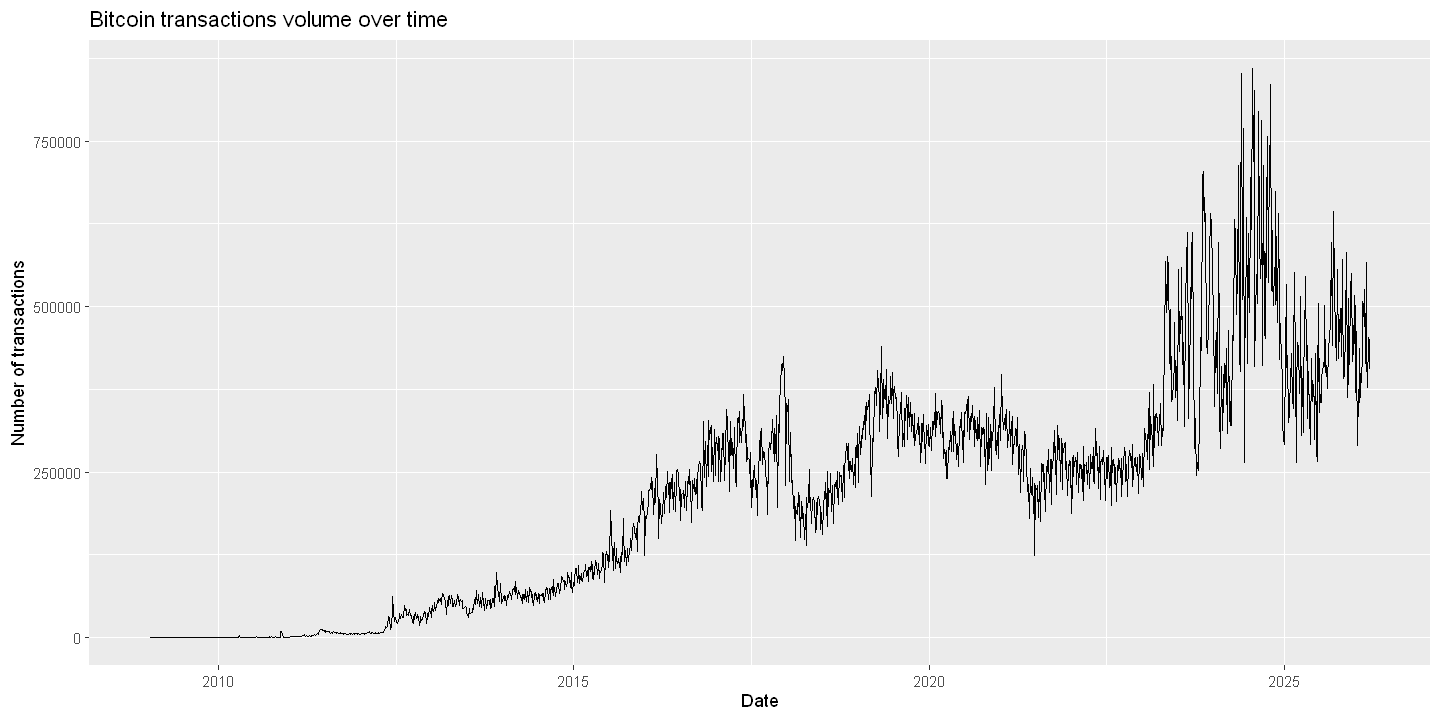

In [7]:
ggplot(df, aes(x = date, y = transactions)) + 
  geom_line() + 
  labs(title = "Bitcoin transactions volume over time", x = "Date", y = "Number of transactions")

# Phase 1 Summary

The dataset contains **1,568 observations**, covering Bitcoin activity from **January 17, 2009** to **March 16, 2026** at approximately **4-day intervals**.

Key findings from the data include:
- A clear long-run upward trend in transaction volume
- Variability that increases over time on the raw scale
- Immediate evidence of non-stationarity before transformation

## 2. Model Specification

### 2.1 Data and Transformation

The raw transaction volume series shows a dramatic upward trend over 17 years, rising from near zero in 2009 to hundreds of thousands of daily transactions by 2026. This level of growth makes the series clearly non-stationary in the mean. To stabilize the variance - which also grows with the level - we apply a natural logarithm transformation. The log-transformed series compresses the explosive early growth and makes the variability more uniform across time.

# Phase 2: Data Validation
In this phase, we validate data by checking for time gaps (very important for time series forecasting), we do this by creating a complete sequence of dates from the minimum to the maximum date in the dataset and then finding missing dates by comparing the full sequence with the dates in the dataset.

In [8]:
full_dates <- data.frame(date = seq(min(df$date), max(df$date), by = "days"))

df$date <- as.Date(df$date)
full_dates$date <- as.Date(full_dates$date)

missing_dates <- full_dates %>%
  anti_join(df, by = "date")

nrow(missing_dates)
head(missing_dates)
# 4701 missing dates, which means data is not daily spaced, after further analysis it appears that data is 4-day spaced (next cell).

[1] 4701

,date
,<date>
1,2009-01-18
2,2009-01-19
3,2009-01-20
4,2009-01-22
5,2009-01-23
6,2009-01-24


In [9]:
diff_days <- diff(df$date)
table(diff_days)
unique(diff(df$date))

diff_days
   4    7 
1565    1 

Time differences in days
[1] 4 7

# Phase 2 Summary:
- Dataset is regularly spaced at 4-day intervals
- No true missing values detected
- Time series is consistent and complete
- No interpolation required

# Phase 3: Time Series Construction
**Objective:** Convert dataframe to a proper time series object usable for analysis and modeling.

In [10]:
install.packages("xts")
library(xts)

Installing package into 'C:/Users/OASIS/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'xts' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\OASIS\AppData\Local\Temp\RtmpgJIVrw\downloaded_packages


Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by 

In [11]:
ts_data <- xts(df$transactions, order.by = df$date)
ts_data
periodicity(ts_data)
ts_base <- ts(df$transactions)

           m.c.seq.row..seq.n...seq.col..drop...FALSE.
2009-01-17                                         109
2009-01-21                                         105
2009-01-25                                         192
2009-01-29                                         122
2009-02-02                                         129
2009-02-06                                         122
2009-02-10                                         120
2009-02-14                                         136
2009-02-18                                         118
2009-02-22                                         125
       ...                                            
2026-02-08                                      507211
2026-02-12                                      484938
2026-02-16                                      526061
2026-02-20                                      413542
2026-02-24                                      566873
2026-02-28                                      424909
2026-03-04

Weekly periodicity from 2009-01-17 to 2026-03-16 

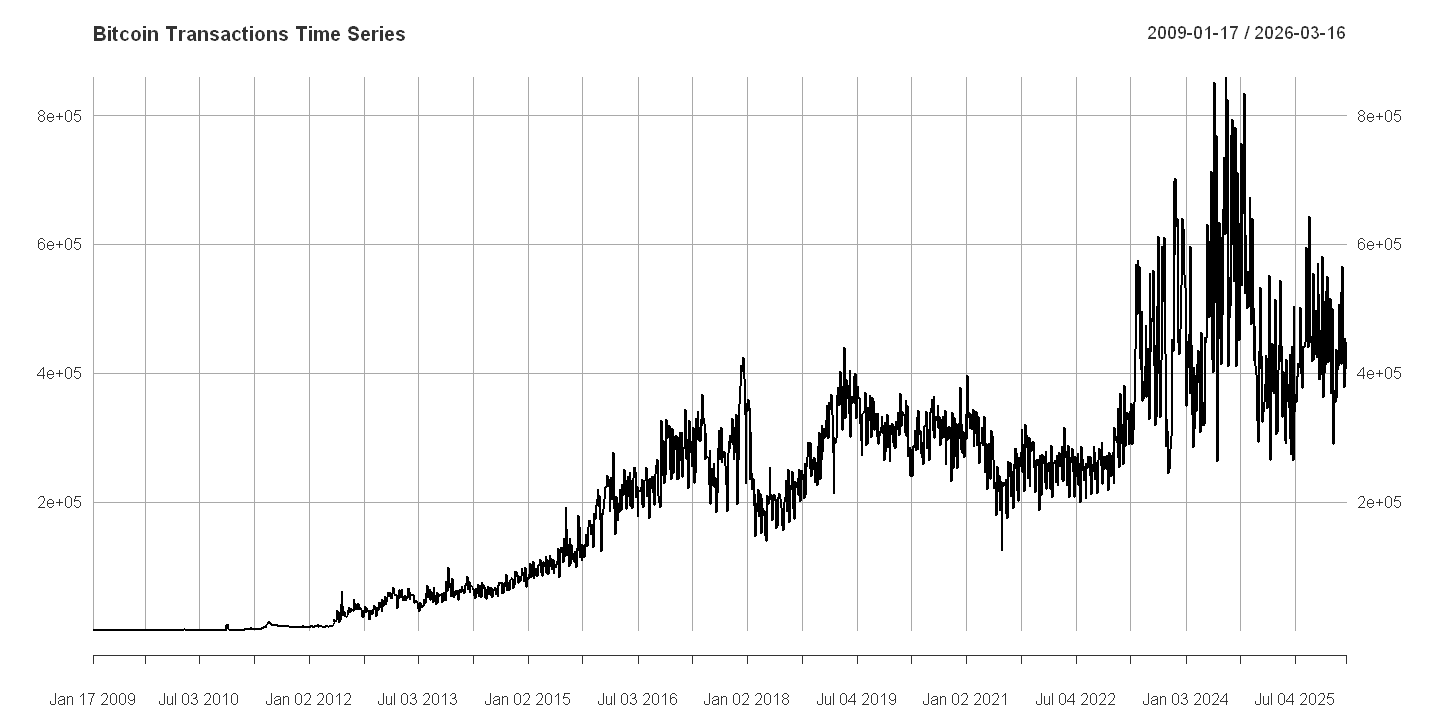

In [12]:
plot(ts_data, main = "Bitcoin Transactions Time Series")

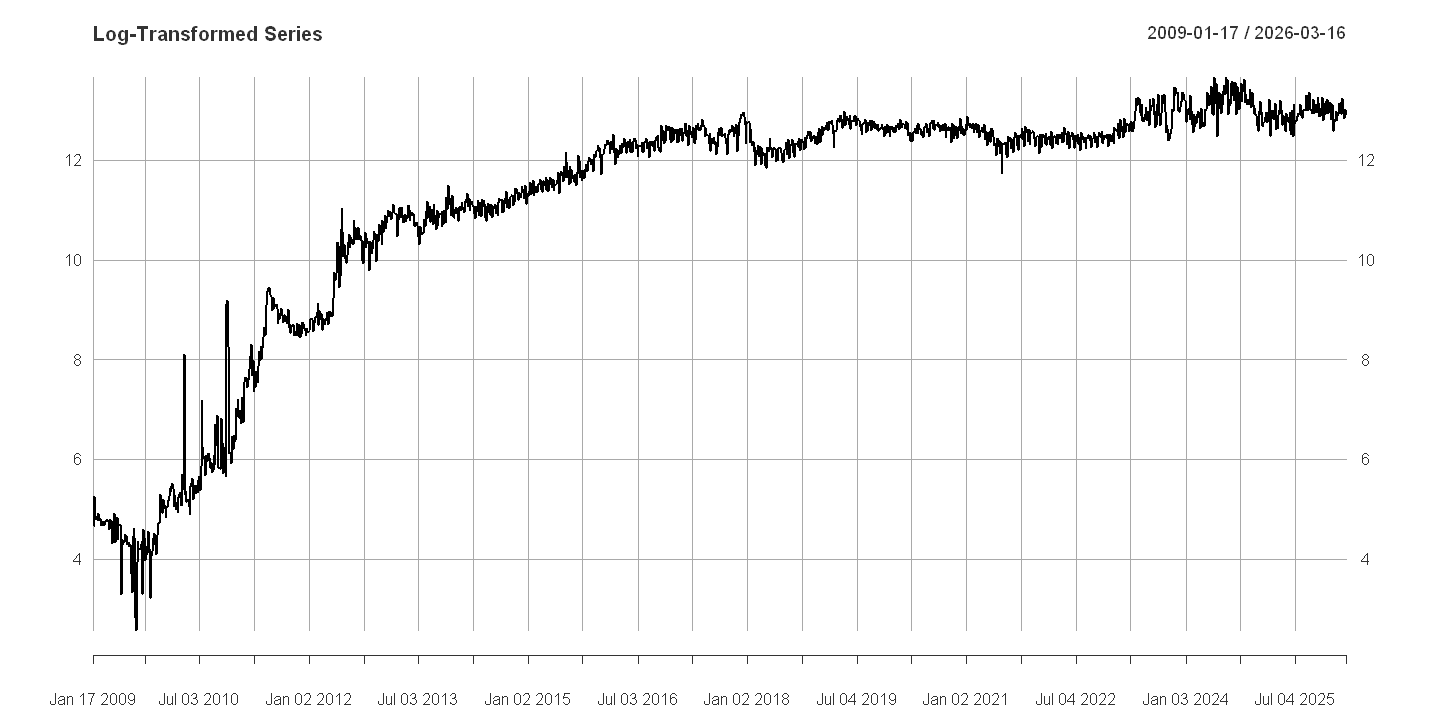

In [13]:
plot(log(ts_data), main = "Log-Transformed Series")

# Phase 3 — Final Conclusion
- The dataset was successfully converted into a time series object using xts
- The time index correctly represents the observation dates
- The series has a regular spacing of 4 days
- Log transformation was applied to stabilize variance
- The transformed series shows a clearer linear trend
- Despite variance stabilization, the series remains non-stationary due to the presence of a trend

# Phase 4: Exploratory Analysis
**Objective**

Identify:

- Trend
- Variance behavior
- Seasonality
- Autocorrelation structure

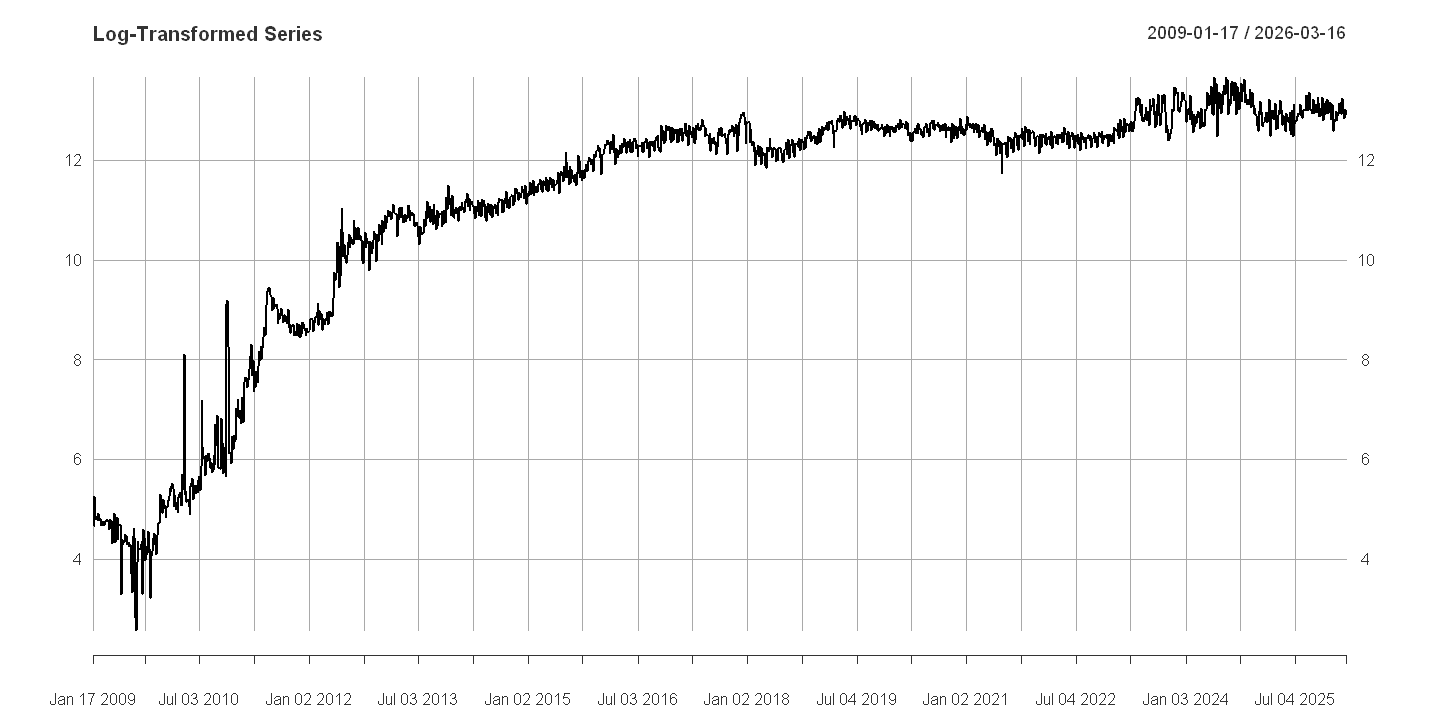

In [21]:
log_ts <- log(ts_data)
plot(log_ts, main = "Log-Transformed Series")

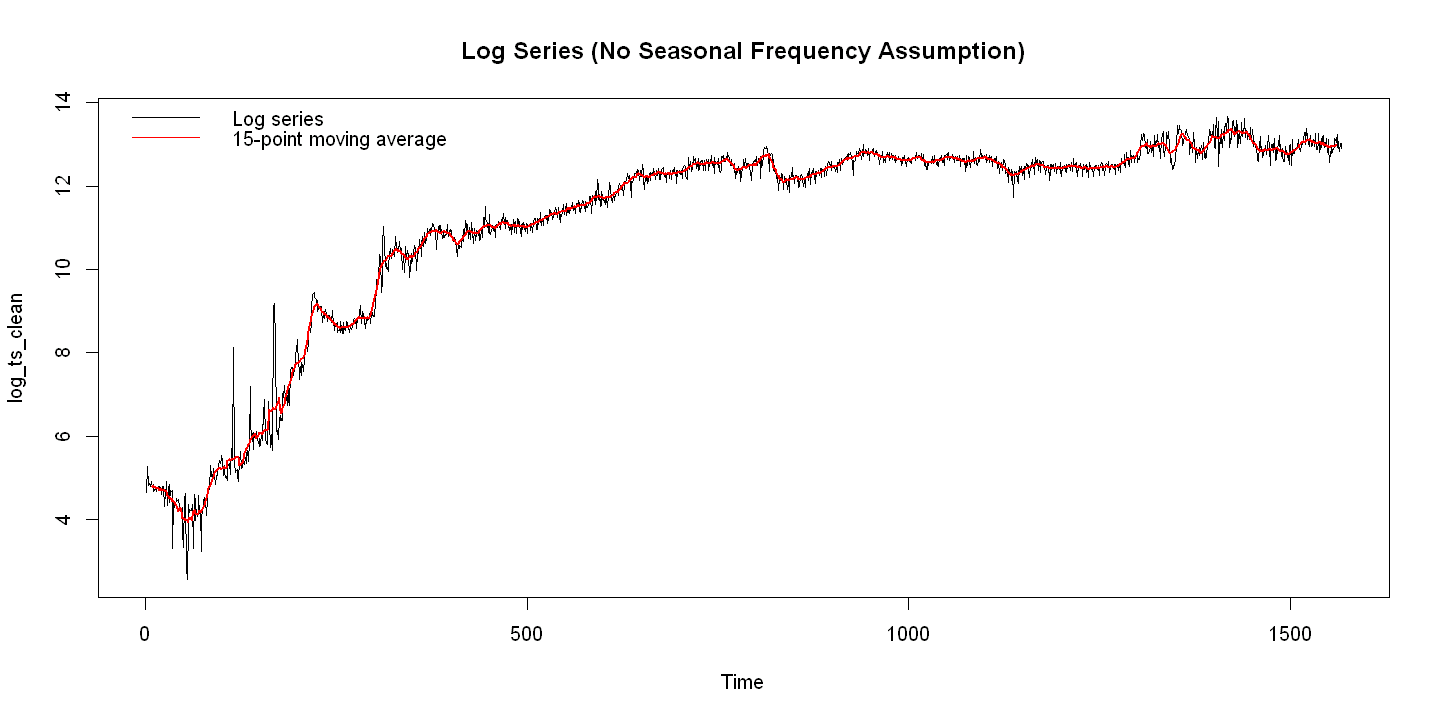

In [22]:
log_vec <- as.numeric(coredata(log_ts))
log_ts_clean <- ts(log_vec, frequency = 1)

plot(log_ts_clean, main = "Log Series (No Seasonal Frequency Assumption)")

trend_smooth <- stats::filter(log_vec, rep(1 / 15, 15), sides = 2)
lines(trend_smooth, col = "red", lwd = 2)
legend("topleft", legend = c("Log series", "15-point moving average"),
       col = c("black", "red"), lty = 1, bty = "n")

**Trend Analysis**

- The series exhibits a clear upward trend
- Growth becomes approximately linear after log transformation
- Indicates non-stationary behavior

**Variance Analysis**

- Log transformation stabilizes variance
- Residual variability remains, especially in recent periods

**Seasonality Check**

- No robust seasonal structure is evident
- The series is dominated by trend, regime shifts, and irregular shocks

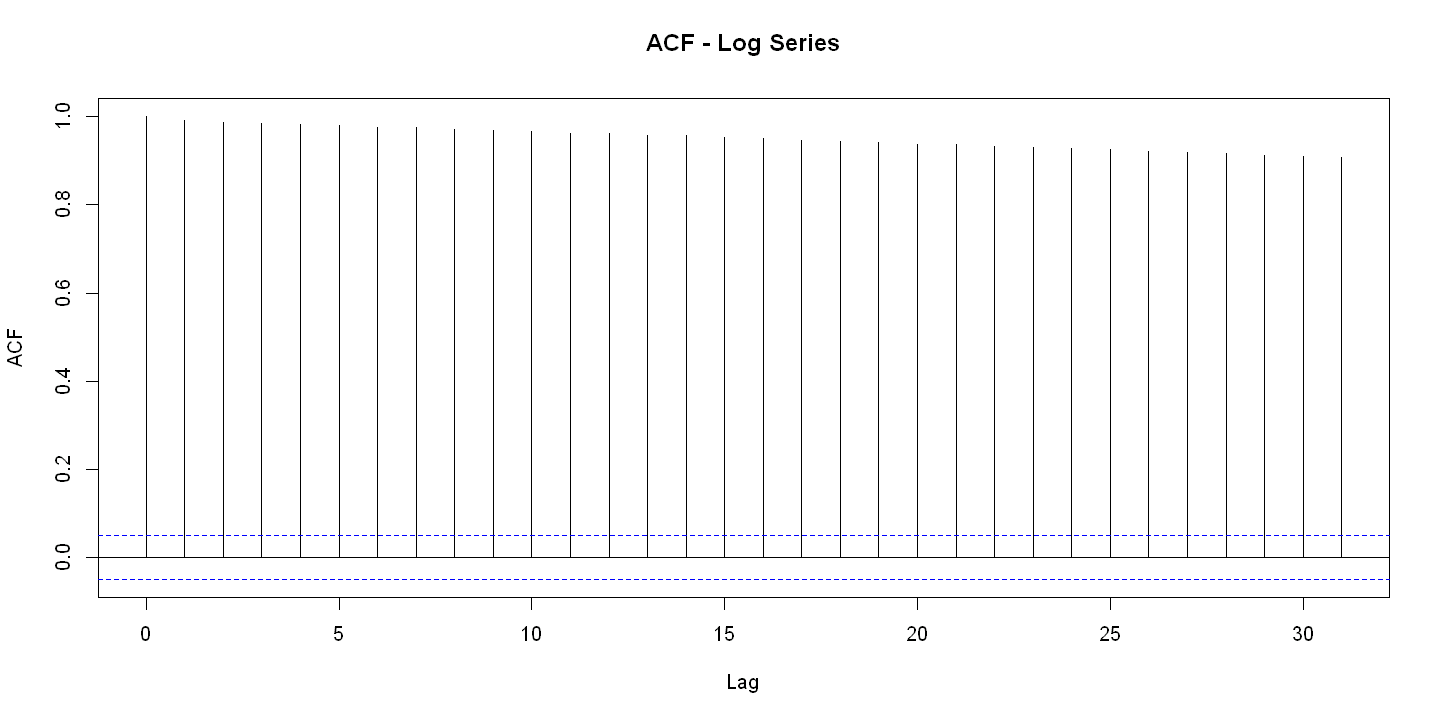

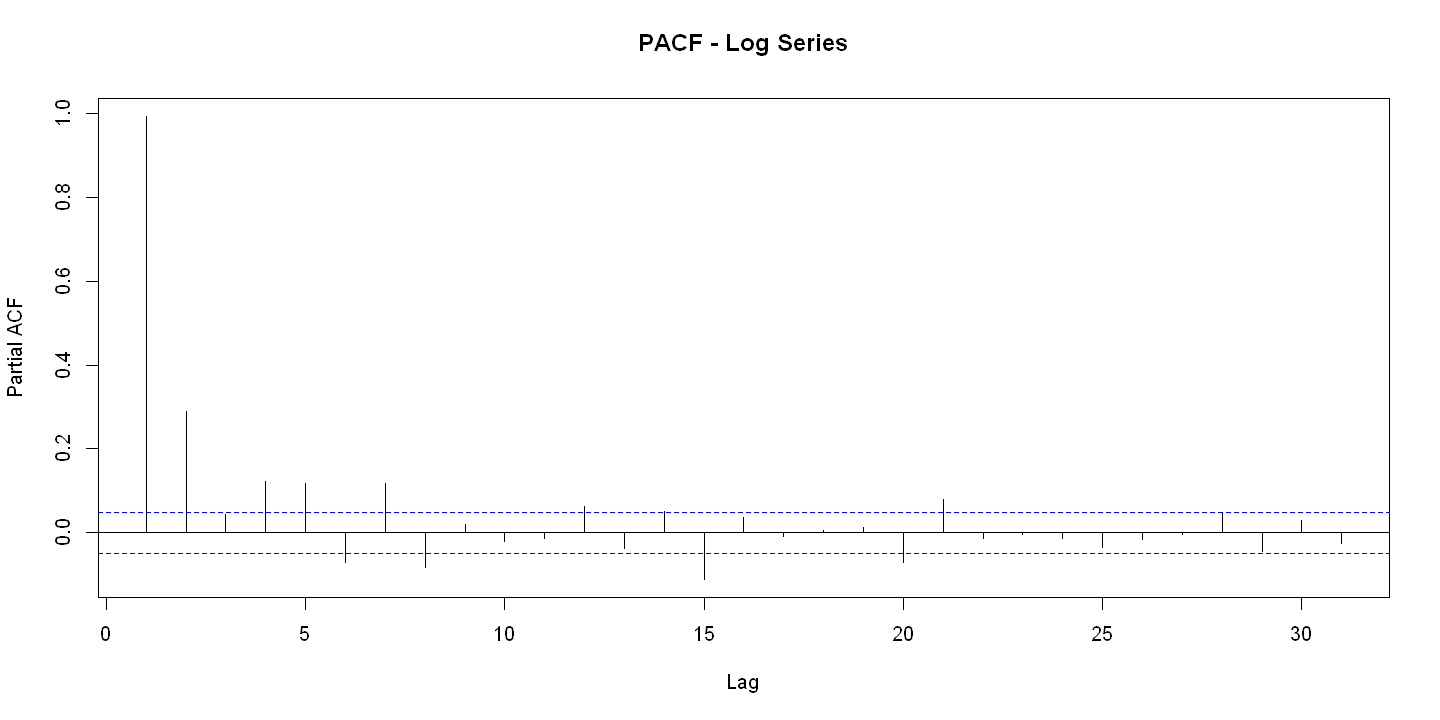

In [23]:
acf(log_ts, main = "ACF - Log Series")
pacf(log_ts, main = "PACF - Log Series")

### 2.2 Stationarity Assessment

The ACF of the log series shows autocorrelations remaining near 1.0 across all 32 lags displayed. This is the signature of a non-stationary series - each observation is strongly dependent on all its predecessors. The PACF shows a dominant spike at lag 1 (≈ 1.0) and cuts off sharply after lag 2, confirming an AR(1)-like random walk structure. Together, these plots provide strong evidence that one degree of differencing (d = 1) is required.

### 2.2.1 Formal Stationarity Tests

Visual inspection is complemented with ADF and KPSS tests to justify differencing decisions statistically rather than only graphically.

In [26]:
diff_for_tests <- diff(log_ts_clean)

adf_level <- adf.test(log_ts_clean)
kpss_level <- kpss.test(log_ts_clean, null = "Level")

adf_diff <- adf.test(diff_for_tests)
kpss_diff <- kpss.test(diff_for_tests, null = "Level")

adf_level
kpss_level
adf_diff
kpss_diff

Warning message in kpss.test(log_ts_clean, null = "Level"):
"p-value smaller than printed p-value"
Warning message in adf.test(diff_for_tests):
"p-value smaller than printed p-value"
Warning message in kpss.test(diff_for_tests, null = "Level"):
"p-value greater than printed p-value"



	Augmented Dickey-Fuller Test

data:  log_ts_clean
Dickey-Fuller = -1.6904, Lag order = 11, p-value = 0.7094
alternative hypothesis: stationary



	KPSS Test for Level Stationarity

data:  log_ts_clean
KPSS Level = 13.715, Truncation lag parameter = 7, p-value = 0.01



	Augmented Dickey-Fuller Test

data:  diff_for_tests
Dickey-Fuller = -15.626, Lag order = 11, p-value = 0.01
alternative hypothesis: stationary



	KPSS Test for Level Stationarity

data:  diff_for_tests
KPSS Level = 0.28373, Truncation lag parameter = 7, p-value = 0.1


Test results from this dataset:

- Level log series: ADF p-value = 0.7094 (fail to reject unit root), KPSS p-value < 0.01 (reject level stationarity).
- First difference: ADF p-value < 0.01 (reject unit root), KPSS p-value > 0.10 (do not reject stationarity).

These results are consistent and support one differencing step (`d = 1`).

[1] 0

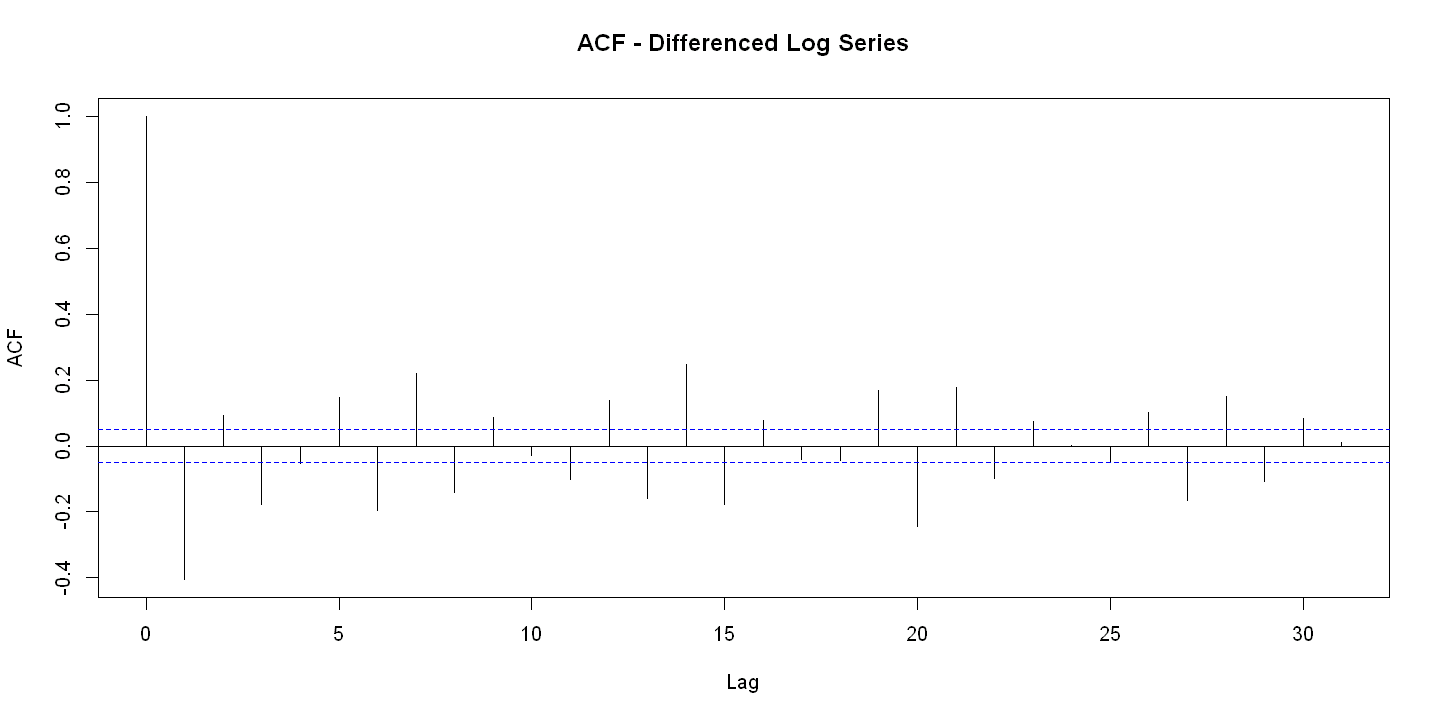

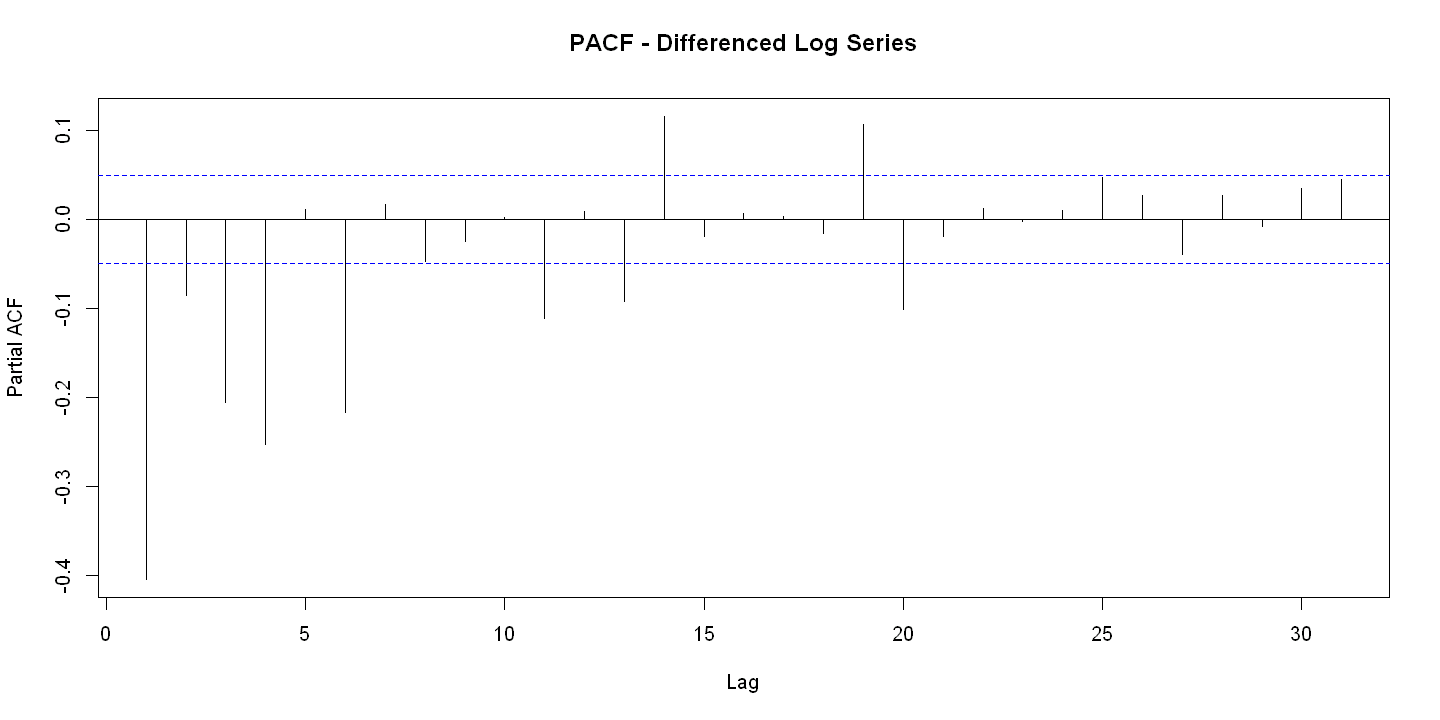

In [27]:
diff_log_clean <- diff(log_ts_clean)
sum(is.na(diff_log_clean))

acf(diff_log_clean,  main = "ACF - Differenced Log Series")
pacf(diff_log_clean, main = "PACF - Differenced Log Series")

### 2.3 Differenced Series

After first differencing, the series represents the change in log volume between consecutive 4-day periods — equivalent to the percentage change in transaction volume. The ACF of the differenced series shows a large negative spike at lag 1 (≈ −0.42) then cuts off, suggesting a Moving Average component. The PACF shows significant spikes at lags 1 through 6 that decay gradually, suggesting an Autoregressive component as well. Several isolated spikes appear at lags 14 and 20, likely reflecting Bitcoin-specific structural effects such as halving cycles rather than pure ARIMA structure.

Based on this visual inspection, candidate models include ARIMA(0,1,1), ARIMA(1,1,1), ARIMA(0,1,2), and ARIMA(1,1,2).

### 2.4 Outlier and Regime-Shift Sensitivity

Bitcoin transaction history includes abrupt jumps tied to market cycles and adoption shifts. To assess robustness, we construct an outlier-cleaned version of the log series using `tsclean()` and compare model performance on original vs cleaned data.

[1] 23

[1]  36  50  54  55  63  73 115 137 167 168

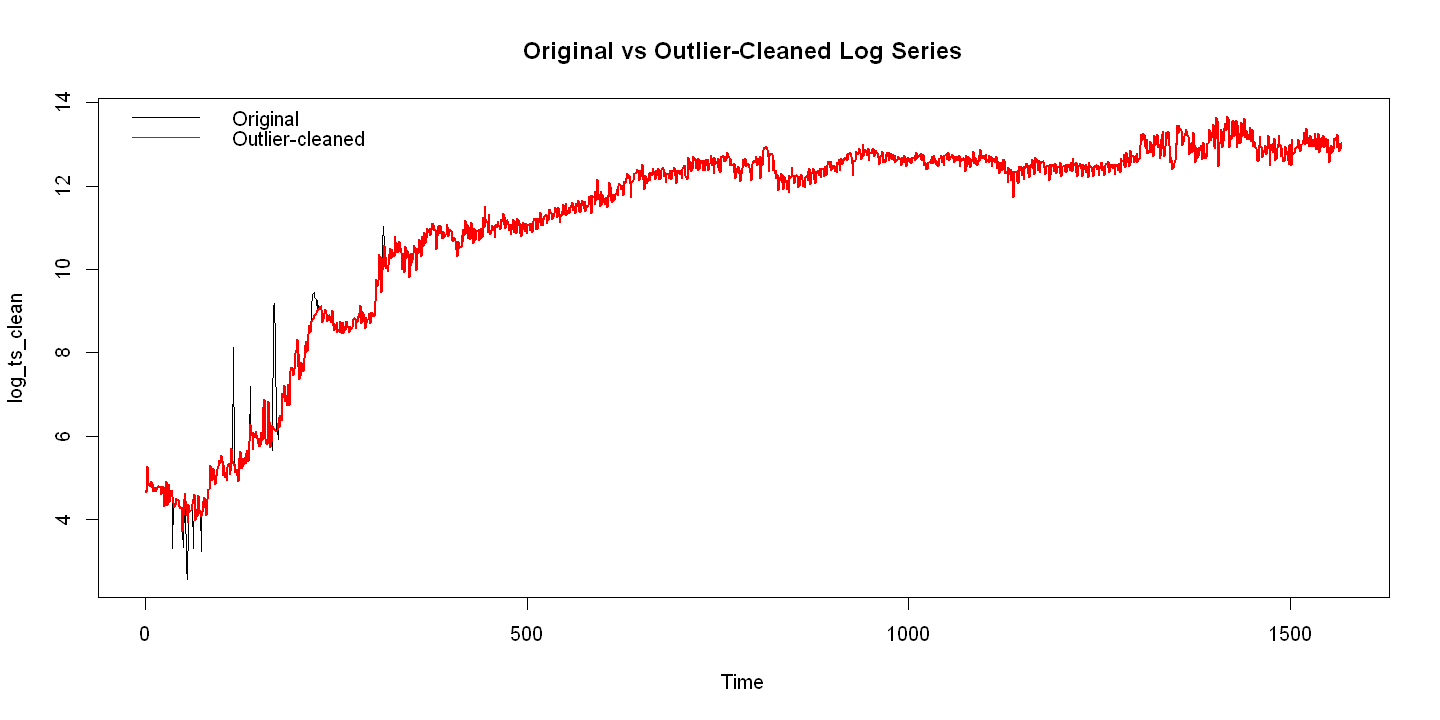

In [28]:
log_ts_outlier_clean <- tsclean(log_ts_clean)
outlier_idx <- which(abs(log_ts_clean - log_ts_outlier_clean) > 1e-8)

length(outlier_idx)
head(outlier_idx, 10)

plot(log_ts_clean, main = "Original vs Outlier-Cleaned Log Series")
lines(log_ts_outlier_clean, col = "red", lwd = 2)
legend("topleft", legend = c("Original", "Outlier-cleaned"),
       col = c("black", "red"), lty = 1, bty = "n")

Outlier sensitivity outcome: `tsclean()` flagged 23 points, but ARIMA on the outlier-cleaned series performed worse on the holdout set (RMSE 0.1721 vs 0.1548 on original data). This suggests the original ARIMA fit is already robust enough for short-horizon forecasting, and aggressive cleaning may remove useful signal along with noise.

In [29]:
# Candidate non-seasonal ARIMA models on the full log series
auto_model <- auto.arima(log_ts_clean,
                         d = 1,
                         seasonal = FALSE,
                         stepwise = FALSE,
                         approximation = FALSE)
summary(auto_model)

m1 <- Arima(log_ts_clean, order = c(0, 1, 1))
m2 <- Arima(log_ts_clean, order = c(1, 1, 1))
m3 <- Arima(log_ts_clean, order = c(0, 1, 2))
m4 <- Arima(log_ts_clean, order = c(1, 1, 2))

aic_table <- AIC(m1, m2, m3, m4)
aic_table[order(aic_table$AIC), ]

Series: log_ts_clean 
ARIMA(2,1,3) with drift 

Coefficients:
          ar1      ar2      ma1     ma2      ma3   drift
      -0.3841  -0.2073  -0.1534  0.0127  -0.3906  0.0052
s.e.   0.1064   0.0734   0.0996  0.0624   0.0446  0.0018

sigma^2 = 0.056:  log likelihood = 37.52
AIC=-61.03   AICc=-60.96   BIC=-23.54

Training set error measures:
                       ME      RMSE       MAE         MPE     MAPE      MASE
Training set 8.317657e-05 0.2361142 0.1478323 -0.06242252 1.665695 0.8279562
                    ACF1
Training set 0.004555046

,df,AIC
,<dbl>,<dbl>
m4,4,6.952338
m2,3,11.612083
m3,3,24.938687
m1,2,45.959792


## 3. Fitting and Diagnostics

### 3.1 Model Selection and Interpretation

Manual AIC comparison among candidate models is reported above, and `auto.arima` is used as a data-driven check under non-seasonal assumptions (`seasonal = FALSE`). The selected ARIMA$(p,d,q)$ model is interpreted as follows:

- `d = 1`: one differencing step removes long-run non-stationary growth in transaction volume.
- `p` (AR terms): persistence from recent changes; if transaction growth was high in recent periods, AR terms propagate part of that momentum.
- `q` (MA terms): correction for short-run shocks/noise; abrupt deviations are partially absorbed by recent forecast errors.

In Bitcoin terms, AR captures momentum in adoption/activity changes, MA captures short-lived transactional shocks, and differencing isolates local growth dynamics rather than absolute level.

,Model,RMSE,MAE,MAPE,MASE
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,ARIMA (original),0.1547716,0.1210592,0.9232097,0.6775395
2,Naive,0.1615043,0.1265928,0.9648642,0.7085100
4,ARIMA (outlier-cleaned),0.1721198,0.1304243,0.9939870,0.8071330
3,ETS,0.1761173,0.1397227,1.0649256,0.7819947


[1] 0.9583125


	Ljung-Box test

data:  Residuals from ARIMA(2,1,3) with drift
Q* = 52.994, df = 5, p-value = 3.373e-10

Model df: 5.   Total lags used: 10




	Box-Ljung test

data:  residuals(final_model)
X-squared = 175.33, df = 14, p-value < 2.2e-16


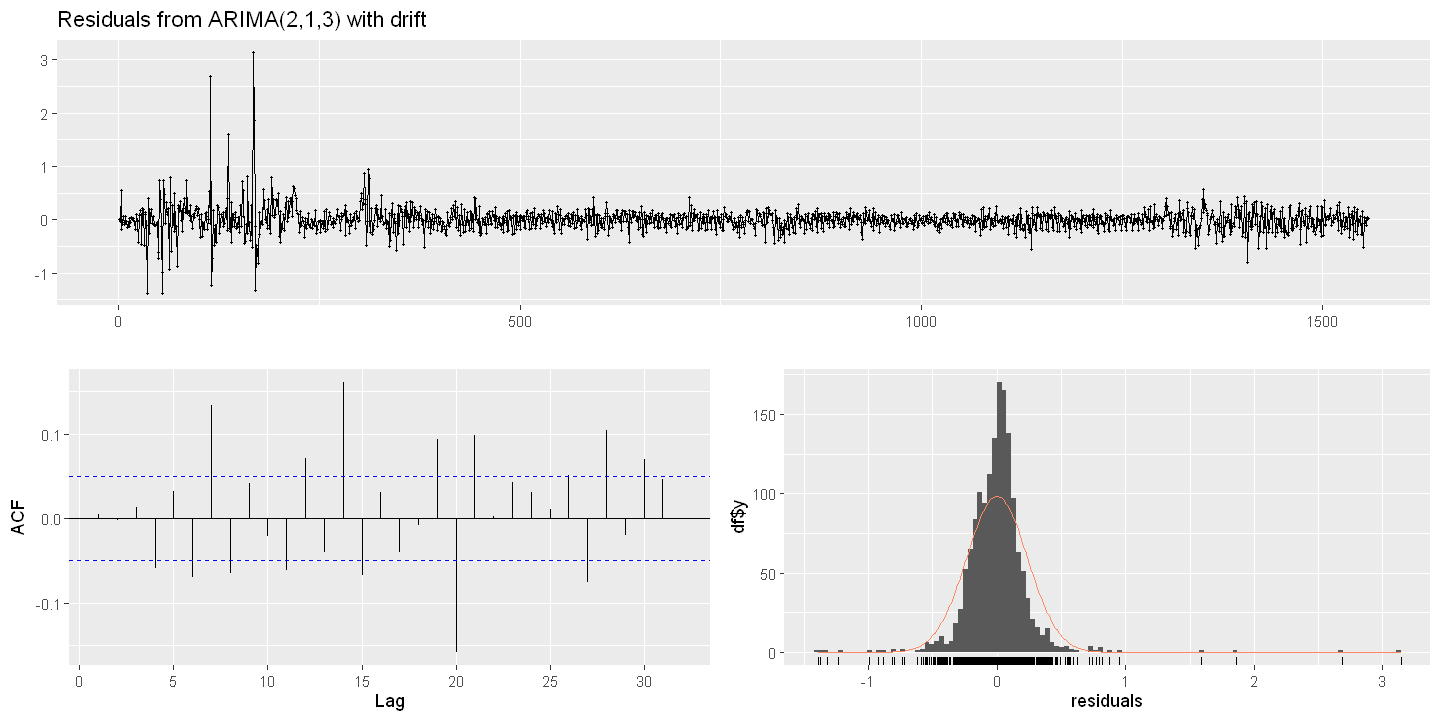

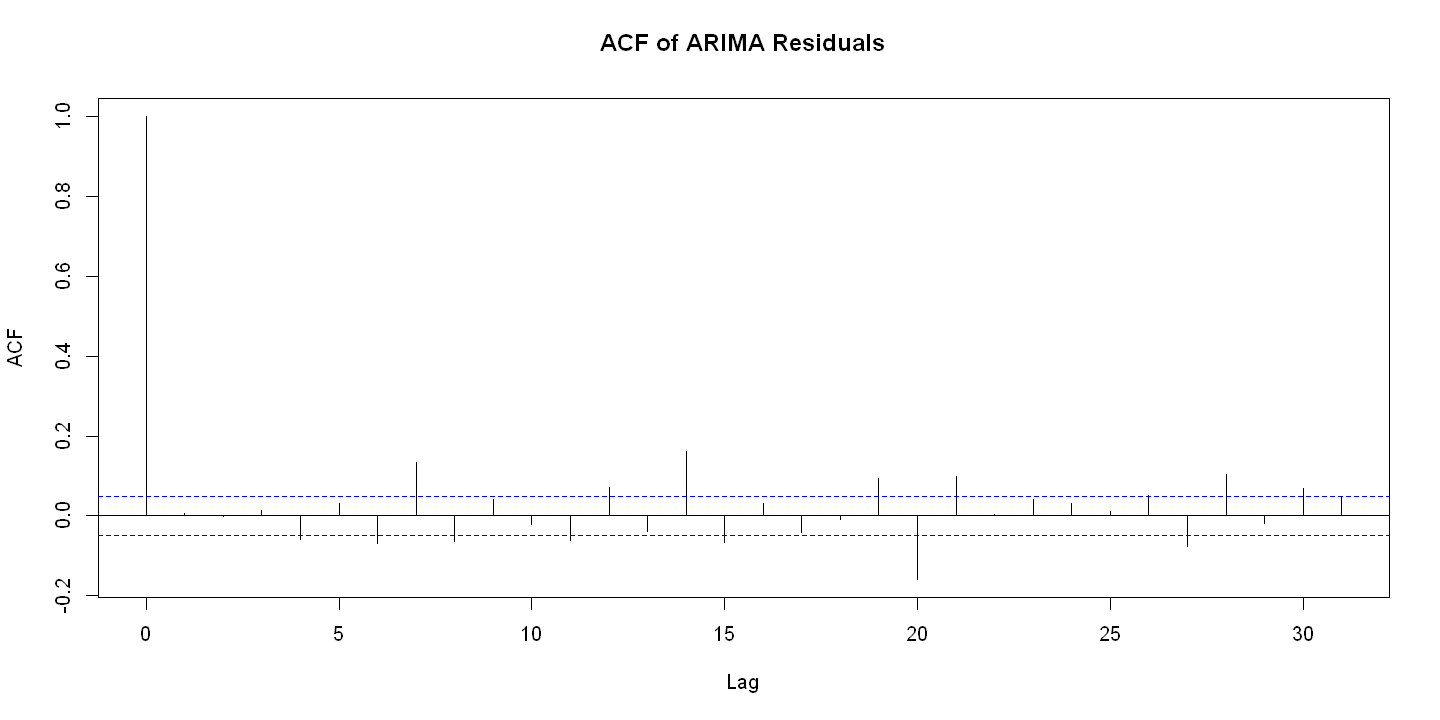

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,8.381673e-05,0.2365179,0.1478612,-0.06270744,1.6694801,0.8275443,0.00463615,NA
Test set,8.578336e-02,0.1547716,0.1210592,0.64908701,0.9232097,0.6775395,-0.03738357,0.8144339


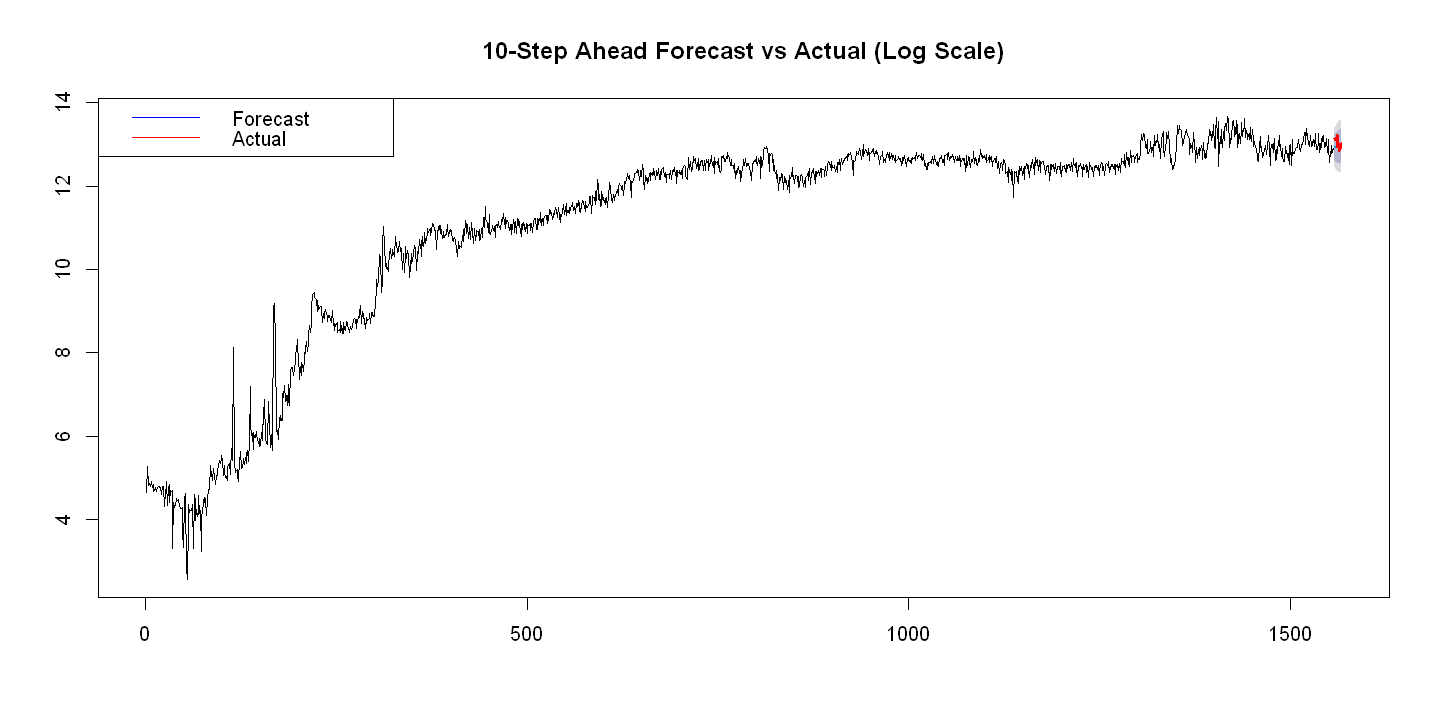

In [31]:
n <- length(log_ts_clean)
train <- head(log_ts_clean, n - 10)
test  <- tail(log_ts_clean, 10)

train_clean <- head(log_ts_outlier_clean, n - 10)
test_clean  <- tail(log_ts_outlier_clean, 10)

final_model <- auto.arima(train,
                          d = 1,
                          seasonal = FALSE,
                          stepwise = FALSE,
                          approximation = FALSE)
fc_arima <- forecast(final_model, h = 10)

naive_model <- naive(train, h = 10)

ets_model <- ets(train, model = "ZZN")
fc_ets <- forecast(ets_model, h = 10)

final_model_clean <- auto.arima(train_clean,
                                d = 1,
                                seasonal = FALSE,
                                stepwise = FALSE,
                                approximation = FALSE)
fc_arima_clean <- forecast(final_model_clean, h = 10)

extract_metrics <- function(fc_obj, actual, model_name) {
  acc <- accuracy(fc_obj, actual)
  data.frame(
    Model = model_name,
    RMSE = as.numeric(acc["Test set", "RMSE"]),
    MAE = as.numeric(acc["Test set", "MAE"]),
    MAPE = as.numeric(acc["Test set", "MAPE"]),
    MASE = as.numeric(acc["Test set", "MASE"]),
    row.names = NULL
  )
}

metrics_table <- rbind(
  extract_metrics(fc_arima, test, "ARIMA (original)"),
  extract_metrics(naive_model, test, "Naive"),
  extract_metrics(fc_ets, test, "ETS"),
  extract_metrics(fc_arima_clean, test_clean, "ARIMA (outlier-cleaned)")
)
metrics_table <- metrics_table[order(metrics_table$RMSE), ]
metrics_table

rmse_ratio_vs_naive <- metrics_table$RMSE[metrics_table$Model == "ARIMA (original)"] /
  metrics_table$RMSE[metrics_table$Model == "Naive"]
rmse_ratio_vs_naive

checkresiduals(final_model)
Box.test(residuals(final_model),
         lag = 20,
         type = "Ljung-Box",
         fitdf = length(final_model$coef))
acf(residuals(final_model), main = "ACF of ARIMA Residuals")

fc <- fc_arima

plot(fc, main = "10-Step Ahead Forecast vs Actual (Log Scale)")
lines(ts(as.numeric(test), start = n - 9), col = "red", lwd = 2)
legend("topleft",
       legend = c("Forecast", "Actual"),
       col    = c("blue", "red"),
       lty    = 1)

accuracy(fc, test)

### 3.2 Residual Diagnostics

Residual checks indicate that the model is useful for forecasting but not fully white-noise in-sample:

- `checkresiduals(final_model)` Ljung-Box p-value = 3.37e-10
- Additional Ljung-Box test at lag 20: p-value < 2.2e-16
- Residual ACF still shows a few significant spikes

Interpretation: short-horizon forecasts are accurate, but remaining dependence suggests unmodeled structure (likely linked to regime changes across Bitcoin eras).

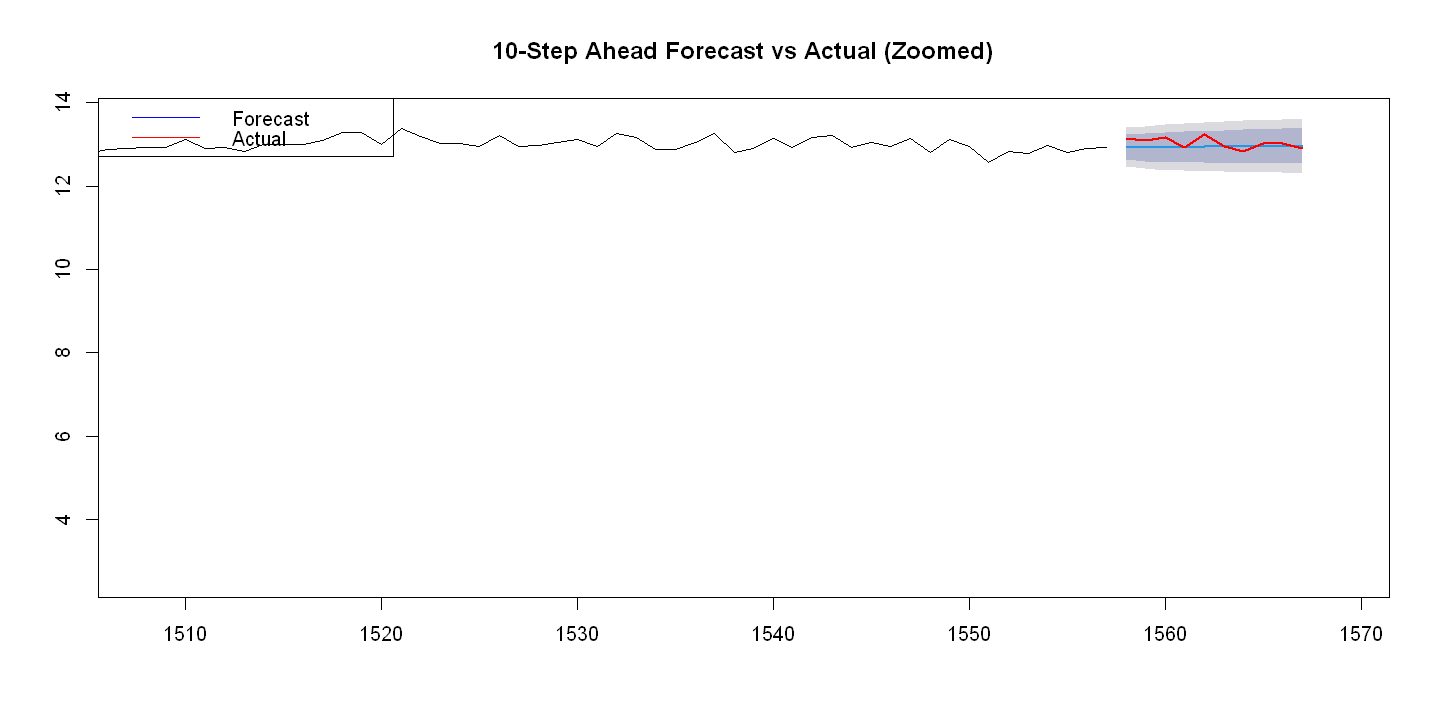

In [32]:
zoom_train <- tail(train, 50)
zoom_start <- n - 10 - 49

plot(fc,
     xlim = c(zoom_start, n + 2),
     main = "10-Step Ahead Forecast vs Actual (Zoomed)")
lines(ts(as.numeric(test), start = n - 9),
      col = "red", lwd = 2)
legend("topleft",
       legend = c("Forecast", "Actual"),
       col = c("blue", "red"), lty = 1)

## 4. Forecasting and Evaluation

### 4.1 Holdout Design

The model is trained on the first `n-10` observations and evaluated on the last 10 observations (about 40 days). This preserves temporal order and avoids data leakage.

### 4.2 Quantitative Comparison

| Model | RMSE | MAE | MAPE | MASE |
|---|---:|---:|---:|---:|
| ARIMA (original) | 0.1548 | 0.1211 | 0.923% | 0.678 |
| Naive | 0.1615 | 0.1266 | 0.965% | 0.709 |
| ARIMA (outlier-cleaned) | 0.1721 | 0.1304 | 0.994% | 0.807 |
| ETS | 0.1761 | 0.1397 | 1.065% | 0.782 |

Interpretation of metrics:

- RMSE penalizes larger errors and is used here as the primary ranking criterion.
- MAE gives the typical absolute forecast error in log units.
- MAPE gives relative error (all models are near 1%, indicating strong short-horizon performance).
- MASE below 1 for all models indicates improvement over a random-walk scale benchmark, with ARIMA performing best.

The original ARIMA model is the best performer across RMSE, MAE, MAPE, and MASE on this holdout split.

## 5. Discussion

### 5.1 Summary

The notebook now follows a stronger statistical workflow: transformation, formal stationarity testing (ADF and KPSS), outlier-sensitivity analysis, non-seasonal ARIMA modeling, baseline comparison (Naive and ETS), and holdout forecasting. This provides a more defensible conclusion than relying on visual checks and a single model only.

### 5.2 Main Problems Encountered

The main challenge remains structural heterogeneity across Bitcoin history. Early years behave differently from recent years, so a single linear model cannot fully represent all regimes. This is why residual diagnostics may still indicate remaining dependence even when short-horizon forecasting is accurate.

Another practical issue is representation of time spacing. Because observations are every 4 days, forcing annual seasonal frequency can introduce artificial seasonality. Treating the series as non-seasonal avoids this misspecification.

### 5.3 Conclusion

For this dataset, a well-specified non-seasonal ARIMA with first differencing is a reasonable and interpretable baseline. However, model quality should be judged against Naive and ETS baselines and validated through residual diagnostics and outlier sensitivity, not by ARIMA fit alone.